# Modelado Estocástico
## Clase 02

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter

### Cargamos los datos del PBI real de Argentina entre 1950 y 2023.

Fuente: Federal Reserve Economic Data - Graph Observations. Federal Reserve Bank of St. Louis
[Real GDP at Constant National Prices for Argentina, Millions of 2021 U.S. Dollars, Annual, Not Seasonally Adjusted](https://fred.stlouisfed.org/series/RGDPNAARA666NRUG)

Leemos el archivo `.csv` y ordenamos sus valores por año.

In [ ]:
df = pd.read_csv("year_gdp_Argentina.csv")
df = df.sort_values(by=["year"]).reset_index(drop=True)
df.head()

,year,gdp
0,1950,237924.281250
1,1951,251976.500000
2,1952,236968.406250
3,1953,246968.125000
4,1954,255009.546875


### Graficamos el PBI real en función del año utilizando `matplotlib`:

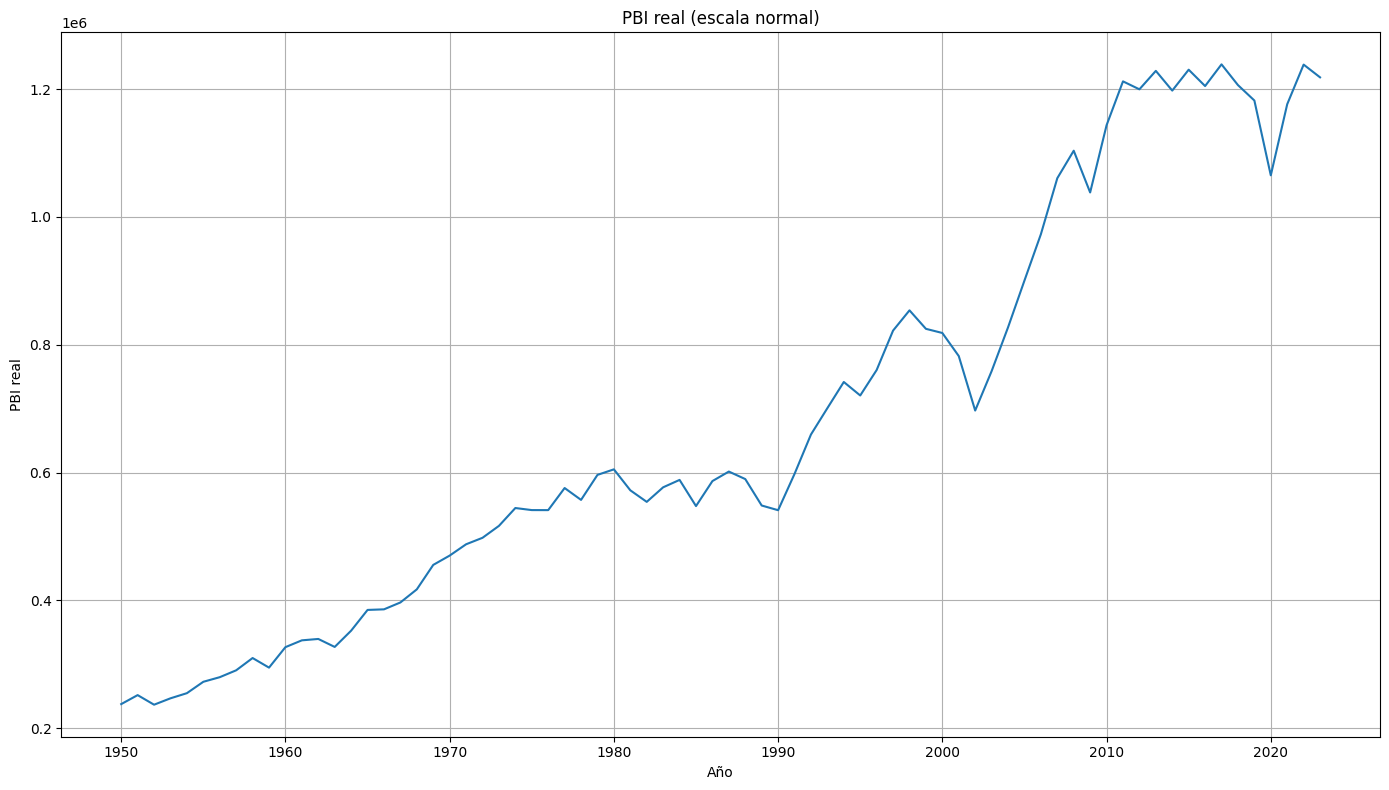

In [ ]:
plt.figure(figsize=(14,8))

plt.plot(df["year"],
         df["gdp"])

plt.xlabel("Año")
plt.ylabel("PBI real")
plt.title("PBI real (escala normal)")
plt.tight_layout()
plt.grid(True)
plt.show()

- Cálculo de la tasa de crecimiento promedio



In [ ]:
primeros_valores = df.iloc[0]
ultimos_valores = df.iloc[-1]

1/(ultimos_valores["year"] - primeros_valores["year"]) * np.log(ultimos_valores["gdp"] / primeros_valores["gdp"])


np.float64(0.022374001822289376)

### Cálculo de escala logarítmica

- Creamos una nueva columna con el logaritmo de los valores correspondientes a cada año


In [ ]:
df["log_pbi"] = np.log(df["gdp"])
df.head()

,year,gdp,log_pbi
0,1950,237924.281250,12.379708
1,1951,251976.500000,12.437091
2,1952,236968.406250,12.375682
3,1953,246968.125000,12.417015
4,1954,255009.546875,12.449056


### Media móvil centrada

- Calculamos la media movil de 11 periodos centrada en la obs contemporanea y la guardamos en una nueva columna. `rolling(window=11, center=True)` crea una ventana deslizante de 11 elementos, con 11 valores consecutivos centrados en el punto actual (es decir, toma 5 antes y 5 después).

In [ ]:
df["ygmm"] = df["log_pbi"].rolling(window=11, center=True).mean()

### Gráfico de Media móvil centrada y Log(PBI)
- Graficamos ambas columnas

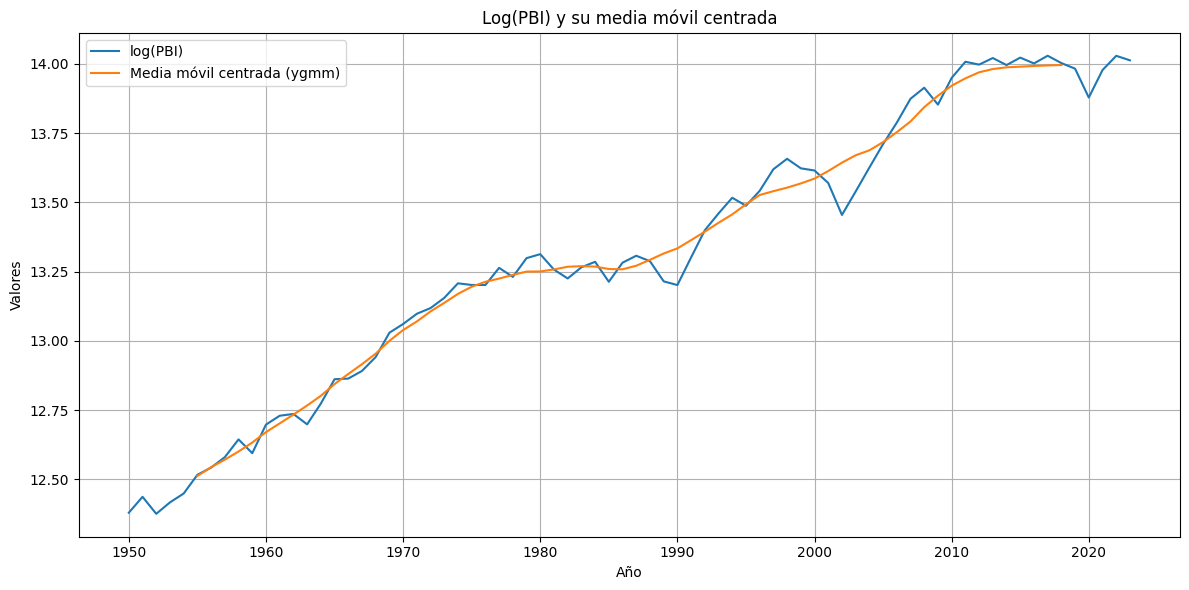

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df["year"], df["log_pbi"], label="log(PBI)")

plt.plot(df["year"], df["ygmm"], label="Media móvil centrada (ygmm)")

plt.xlabel("Año")
plt.ylabel("Valores")
plt.title("Log(PBI) y su media móvil centrada")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

### Componente cíclico

- Calculamos el componente cíclico como la diferencia entre ambos valores (log(PBI) y media móvil centrada)
- Graficamos

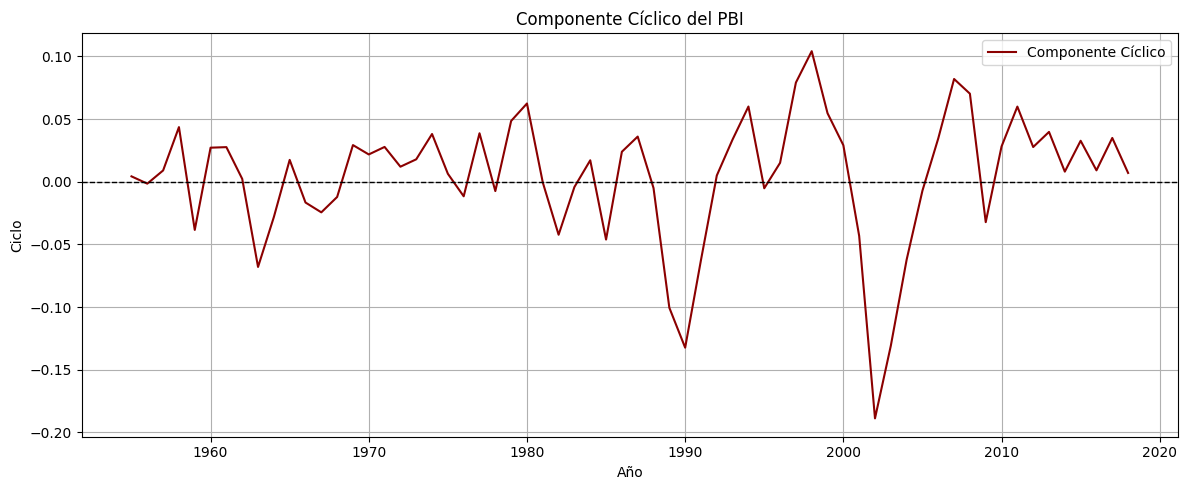

In [ ]:
df["ciclo"] = df["log_pbi"] - df["ygmm"]
plt.figure(figsize=(12, 5))

plt.plot(df["year"], df["ciclo"], label="Componente Cíclico", color="darkred")

plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Año")
plt.ylabel("Ciclo")
plt.title("Componente Cíclico del PBI")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


### Filtro Hodrick y Prescott

- Obtenemos ciclo y tendencia con `lambda = 100` para datos anuales.

In [ ]:
cycle, trend = hpfilter(df["log_pbi"], lamb=100)
df["y_g"] = trend
df["y_c"] = cycle

- Graficamos ciclo

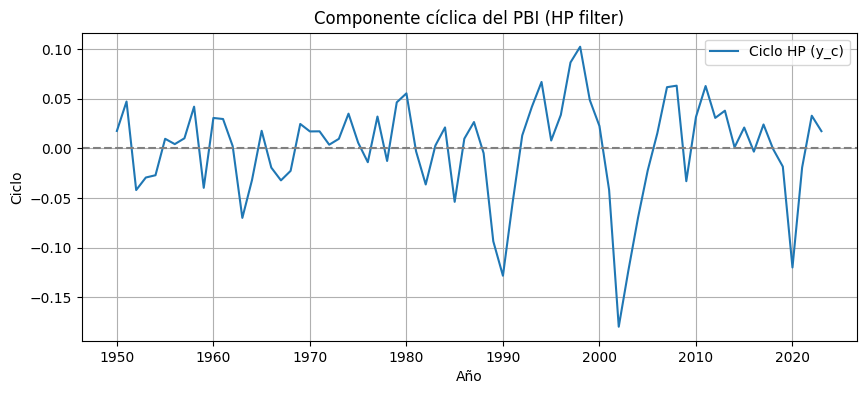

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df["year"], df["y_c"], label="Ciclo HP (y_c)")
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Año")
plt.ylabel("Ciclo")
plt.title("Componente cíclica del PBI (HP filter)")
plt.legend()
plt.grid(True)
plt.show()

- Graficamos el logaritmo del PBI y tendencia.

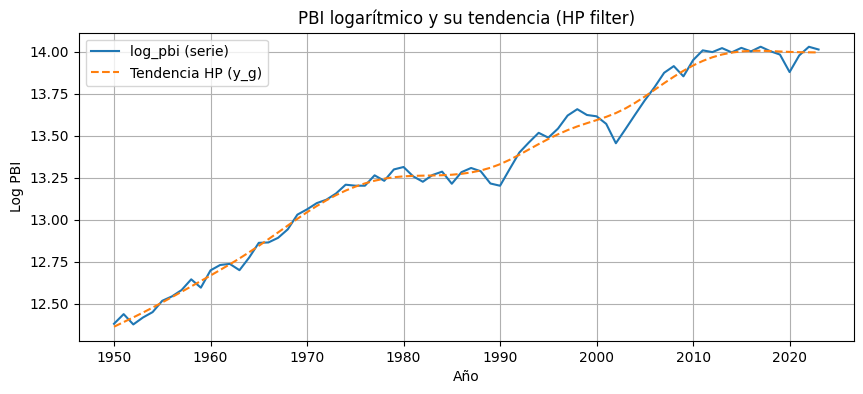

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(df["year"], df["log_pbi"], label="log_pbi (serie)")
plt.plot(df["year"], df["y_g"], label="Tendencia HP (y_g)", linestyle='--')
plt.xlabel("Año")
plt.ylabel("Log PBI")
plt.title("PBI logarítmico y su tendencia (HP filter)")
plt.legend()
plt.grid(True)
plt.show()